# Exercise 7 - Simulated annealing for the TSP

Simulated annealing = Metropolis-Hastings + a cooling temperature scheme. We target
$P_T(x)\propto e^{-f(x)/T}$, so a swap proposal is accepted with
$\alpha=\min\!\big(1,e^{-(f(Y)-f(X))/T_k}\big)$: improving moves are always accepted, worsening
moves only sometimes. As $T_k\to0$ the chain concentrates on the minimum.

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations

rng = np.random.default_rng(2026)
plt.rcParams["figure.figsize"] = (10, 4)


def dist_matrix(P):
    """Euclidean distance matrix of points P (one row per point)."""
    d = P[:, None, :] - P[None, :, :]
    return np.sqrt((d ** 2).sum(-1))


def tour_cost(route, D):
    """Total cost of a closed tour: sum of D[S_i, S_{i+1}] plus the return edge."""
    return D[route, np.roll(route, -1)].sum()


def propose_swap(route, rng):
    """Swap two randomly chosen positions (symmetric proposal)."""
    p = route.copy()
    i, j = rng.integers(0, len(route), 2)
    p[i], p[j] = p[j], p[i]
    return p


def propose_reverse(route, rng):
    """Reverse a random segment of the route (symmetric)."""
    n = len(route)
    i, j = sorted(rng.integers(0, n, 2))
    p = route.copy()
    p[i:j + 1] = p[i:j + 1][::-1]
    return p


def schedule(T0, kind):
    """Cooling schemes from the exercise, scaled by a problem-scale constant T0."""
    if kind == "sqrt":
        return lambda k: T0 / np.sqrt(1 + k)
    return lambda k: T0 / np.log(2 + k) # kind == "log"


def simulated_annealing(D, cooling, iters, rng, propose=propose_swap, init=None):
    """SA = Metropolis with acceptance min(1, exp(-(f(Y)-f(X))/T_k)) and cooling T_k."""
    route = rng.permutation(len(D)) if init is None else np.array(init)
    c = tour_cost(route, D)
    best, best_c = route.copy(), c
    hist = np.empty(iters + 1); hist[0] = c
    for k in range(iters):
        T = cooling(k)
        prop = propose(route, rng)
        cp = tour_cost(prop, D)
        if cp <= c or rng.random() < np.exp(-(cp - c) / T):
            route, c = prop, cp
            if c < best_c:
                best, best_c = route.copy(), c
        hist[k + 1] = c
    return best, best_c, hist


def plot_route(P, route, ax, title):
    r = np.r_[route, route[0]]
    ax.plot(P[r, 0], P[r, 1], "-o", ms=4)
    ax.scatter(P[:, 0], P[:, 1], c="C3", zorder=3, s=20)
    ax.set_title(title); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])

## Part 1 - Euclidean TSP, swap proposal

State = a route; cost = closed-tour Euclidean length; proposal = swap two cities (symmetric).
Cooling schemes $T_k=1/\sqrt{1+k}$ and $T_k=1/\ln(2+k)$.

**Sanity check.** Points on a circle: the optimum is the regular polygon visiting them in
angular order, of length $n\cdot2\sin(\pi/n)$.

circle n=20:  SA best = 6.2574   optimal polygon = 6.2574   ratio = 1.0000


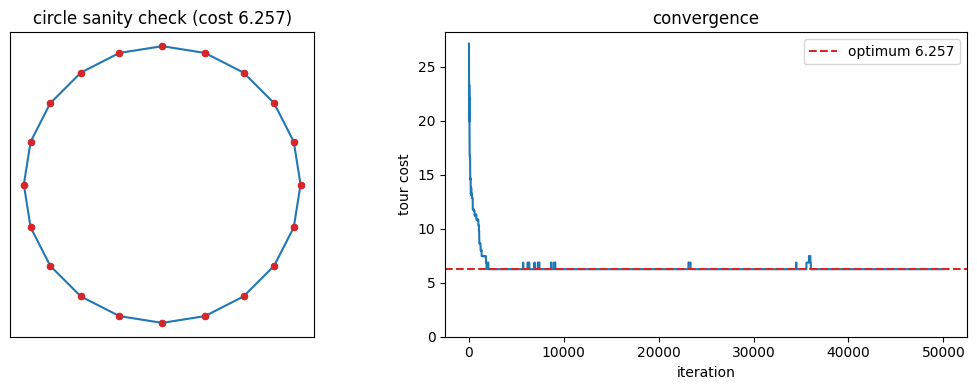

In [ ]:
n = 20
ang = np.linspace(0, 2 * np.pi, n, endpoint=False)
circle = np.c_[np.cos(ang), np.sin(ang)]
D = dist_matrix(circle)
opt = n * 2 * np.sin(np.pi / n) # perimeter of the regular n-gon = optimum

best, best_c, hist = simulated_annealing(D, schedule(1.0, "log"), 50_000, rng)
print(f"circle n={n}:  SA best = {best_c:.4f}   optimal polygon = {opt:.4f}   ratio = {best_c / opt:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
plot_route(circle, best, ax[0], f"circle sanity check (cost {best_c:.3f})")
ax[1].plot(hist); ax[1].axhline(opt, ls="--", color="C3", label=f"optimum {opt:.3f}")
ax[1].set_ylim(bottom=0); ax[1].set_xlabel("iteration"); ax[1].set_ylabel("tour cost")
ax[1].set_title("convergence"); ax[1].legend(); plt.tight_layout(); plt.show()

**Random points.** No closed form, so we keep the best of a few independent runs.

random n=20:  best tour cost over 5 runs = 3.9452


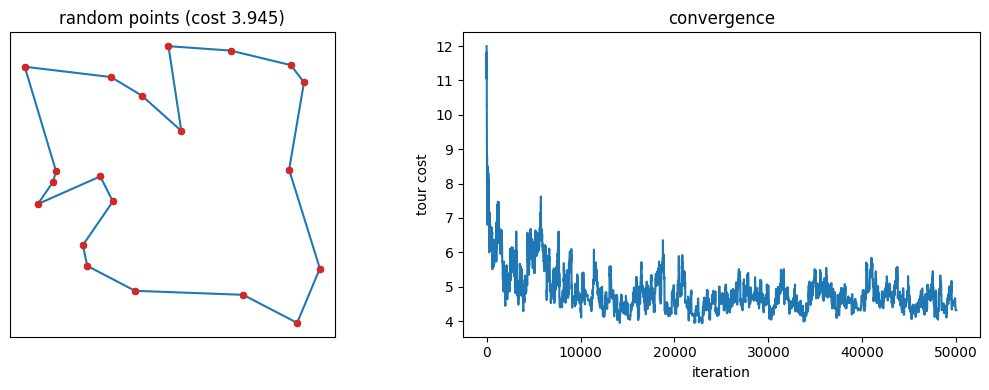

In [ ]:
n = 20
pts = rng.random((n, 2))
D = dist_matrix(pts)
runs = [simulated_annealing(D, schedule(1.0, "log"), 50_000, rng) for _ in range(5)]
best, best_c, hist = min(runs, key=lambda r: r[1]) # keep the best of a few runs
print(f"random n={n}:  best tour cost over 5 runs = {best_c:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
plot_route(pts, best, ax[0], f"random points (cost {best_c:.3f})")
ax[1].plot(hist); ax[1].set_xlabel("iteration"); ax[1].set_ylabel("tour cost")
ax[1].set_title("convergence"); plt.tight_layout(); plt.show()

**The two cooling schemes.** Slower cooling explores longer and is less likely to get trapped in
local optima (fast cooling may give poor solutions).

In [ ]:
n = 30 # a harder circle to separate the schedules
ang = np.linspace(0, 2 * np.pi, n, endpoint=False)
C = np.c_[np.cos(ang), np.sin(ang)]
D = dist_matrix(C)
opt = n * 2 * np.sin(np.pi / n)
for kind, label in [("sqrt", "1/sqrt(1+k)"), ("log", "1/ln(2+k)")]:
    hits = sum(abs(simulated_annealing(D, schedule(1.0, kind), 20_000, rng)[1] - opt) < 1e-6
               for _ in range(10))
    print(f"T_k = {label:11s}:  reached the optimum in {hits}/10 runs")

T_k = 1/sqrt(1+k):  reached the optimum in 2/10 runs


T_k = 1/ln(2+k)  :  reached the optimum in 5/10 runs


## Part 2 - General travel costs

The same algorithm now runs on a general 20-city cost matrix `cost.csv`, which is asymmetric
($A_{ij}\ne A_{ji}$). Only the cost matrix changes - the state, objective and proposals are exactly
those of Part 1. We compare the two cooling schemes and the swap / reverse proposals, scaling the
temperature to the spread of the costs.

20 cities;  initial route 1..20 costs 3404


  sqrt + swap   :  best = 804   median = 996


  sqrt + reverse:  best = 795   median = 805


  log  + swap   :  best = 795   median = 806


  log  + reverse:  best = 788   median = 795

best tour found:  cost = 788   route = [1, 13, 4, 3, 11, 20, 7, 18, 17, 10, 16, 8, 5, 19, 15, 2, 9, 14, 12, 6]


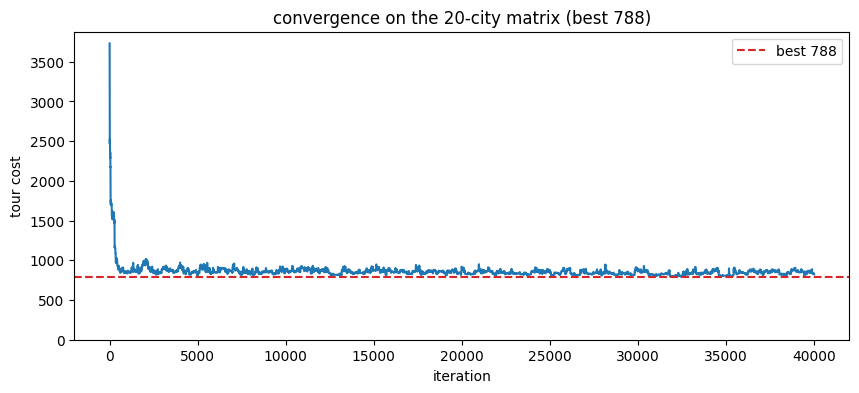

In [ ]:
A = np.loadtxt("cost.csv", delimiter=",") # 20-city travel-cost matrix (asymmetric)
n = len(A)
init = np.arange(n)
print(f"{n} cities;  initial route 1..{n} costs {tour_cost(init, A):.0f}")

scale = A[A > 0].std() # temperature scale for these larger costs
results = {}
for kind in ["sqrt", "log"]:
    for pname, propose in [("swap", propose_swap), ("reverse", propose_reverse)]:
        runs = [simulated_annealing(A, schedule(scale, kind), 40_000, rng, propose)
                for _ in range(10)]
        costs = [r[1] for r in runs]
        results[(kind, pname)] = min(runs, key=lambda r: r[1])
        print(f"  {kind:4s} + {pname:7s}:  best = {min(costs):.0f}   median = {np.median(costs):.0f}")

best, best_c, hist = min(results.values(), key=lambda r: r[1])
order = np.roll(best, -list(best).index(0)) + 1 # rotate so the route starts at city 1
print(f"\nbest tour found:  cost = {best_c:.0f}   route = {order.tolist()}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist)
ax.axhline(best_c, ls="--", color="C3", label=f"best {best_c:.0f}")
ax.set_ylim(bottom=0)
ax.set_xlabel("iteration"); ax.set_ylabel("tour cost")
ax.set_title(f"convergence on the {n}-city matrix (best {best_c:.0f})")
ax.legend(); plt.show()

**Reading Part 2.** SA drives the tour down from the initial 3404 to about 788. The slower $\ln$
schedule together with the reverse proposal is the most reliable - those runs cluster tightly
near the best tour, whereas the swap proposal scatters much more on a problem of this size. Any other
instance is solved by simply replacing `cost.csv`.